Model Expected Input: (None, 48, 48, 1), Provided: (1, 48, 48, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step


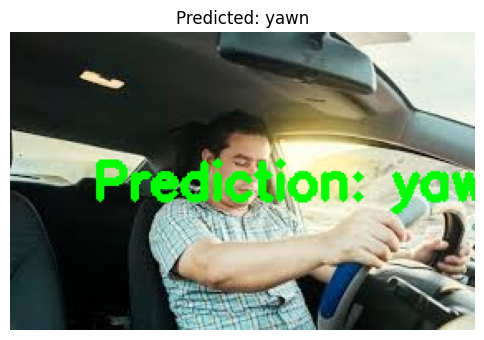

True

In [1]:
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Load the trained model
model = tf.keras.models.load_model("models/drowsiness_model.keras")  # Update with the correct path

# Load the high-resolution image
image_path = r"C:\Users\JAYESH\Downloads\dsd.jpeg"# Replace with actual image path
high_res_image = cv2.imread(image_path)  # Read in color (BGR)

# Convert to grayscale for model prediction
gray_image = cv2.cvtColor(high_res_image, cv2.COLOR_BGR2GRAY)

# Resize for model prediction (48x48)
image_resized = cv2.resize(gray_image, (48, 48))

# Normalize pixel values
image_normalized = image_resized / 255.0

# Expand dimensions to match (1, 48, 48, 1)
image_expanded = np.expand_dims(image_normalized, axis=0)  # Add batch dimension
image_expanded = np.expand_dims(image_expanded, axis=-1)  # Add channel dimension

# Ensure correct shape
print(f"Model Expected Input: {model.input_shape}, Provided: {image_expanded.shape}")

# Predict the class
predictions = model.predict(image_expanded)
predicted_class = np.argmax(predictions, axis=1)[0]
class_labels = ["Closed", "Open", "no_yawn", "yawn"]  # Update based on your classes
predicted_label = class_labels[predicted_class]

# Annotate the high-resolution image
font = cv2.FONT_HERSHEY_SIMPLEX
cv2.putText(high_res_image, f"Prediction: {predicted_label}", (50, 100), font, 1, (0, 255, 0), 3)

# Convert BGR to RGB for correct display
high_res_image_rgb = cv2.cvtColor(high_res_image, cv2.COLOR_BGR2RGB)

# Display the annotated high-resolution image
plt.figure(figsize=(6, 6))
plt.imshow(high_res_image_rgb)
plt.axis("off")
plt.title(f"Predicted: {predicted_label}")
plt.show()

# Save the output image
cv2.imwrite("output_image.png", high_res_image)
